# Lesson 0 - Part 1: LLM basics

After this tutorial, you'll understand the following basics:
- ✅ How to call Claude via API
- ✅ What tokens are
- ✅ How embeddings work

In [2]:
import anthropic
import os
from dotenv import load_dotenv

load_dotenv()
client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))

### Your first API call

You've probably used Claude or ChatGPT before.

But here’s the key question:
👉 *how do we actually talk to a model from code?*

In this cell, we’ll make our **first real API call**.

Don’t worry about understanding every parameter yet, just focus on the idea:
we send a message → the model responds.

In [10]:
# call the Claude API
response = client.messages.create(
    model="claude-haiku-4-5",
    max_tokens=100,
    messages=[
        # Ask our question
        {"role": "user", "content": "What is the best private university of Mexico? Be brief."}
    ]
)

# Print the response and token usage
print(response.content[0].text)
print(f"Tokens used: {response.usage.input_tokens} input, {response.usage.output_tokens} output")

# Best Private University in Mexico

**ITESM (Tecnológico de Monterrey)** is generally considered the top private university in Mexico, known for its strong engineering, business, and technology programs, along with excellent international rankings and industry connections.

**Other highly-regarded options** include Universidad Anáhuac and Universidad Panamericana, depending on the field of study.
Tokens used: 19 input, 86 output


### Tokens: what are they?

Before going further, we need to understand **tokens**.

Think of tokens as the “units” the model reads.

For example:
- "hello" → might be 1 token  
- "I'm excited to learn agentic RAG!" → multiple tokens  

! Important:
Tokens are *not exactly words*. Sometimes a word is split into multiple tokens.

Why does this matter?
* Because **you pay per token** and models have **token limits**.

In [11]:
# Count the tokens of our previous message
token_count_response = client.messages.count_tokens(
    model="claude-haiku-4-5",
    messages=[
        {"role": "user", "content": "What is the best private university of Mexico? Be brief."}
    ]
)

print(token_count_response.model_dump_json())

# Try with a different message and see how many tokens it has!

{"input_tokens":19}


### Pricing

Every time you call a model, you’re paying for:

- **Input tokens** (what you send)
- **Output tokens** (what the model generates)

For Claude Haiku 4.5:
- $1 per 1M input tokens  
- $5 per 1M output tokens  

Intuition:
Output is more expensive because generating text is harder than reading it.

In the next cell, we’ll compute the cost of *our exact request*.

In [13]:
# Calculate: (input_tokens * 3 + output_tokens * 15) / 1_000_000
input_tokens = response.usage.input_tokens
output_tokens = response.usage.output_tokens
cost = (input_tokens * 1 + output_tokens * 5) / 1_000_000
print(f"Cost of this call: {cost:.6f} USD")

Cost of this call: 0.000449 USD


### Embeddings: 

Now let’s look at one of the most important ideas in modern AI: **embeddings**.

An embedding is just a way to turn text into numbers (a vector) that the AI model can understand.

But here’s the cool part:
* similar sentences → similar vectors

In [34]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
sentences = ["I love cats", "Cats are great", "six seven"]
embeddings = model.encode(sentences)
print(f"Embedding shape: {embeddings[0].shape}")
print(f"First embedding: {embeddings[0][:5]}...")  # Show first 5 values

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6109.48it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: (384,)
First embedding: [ 0.03076873 -0.01321542  0.06752616 -0.00369999 -0.06508701]...


👉 Before running this:
Which pair do you think will be more similar?

1. "I love cats" vs "Cats are great"  
2. "I love cats" vs "six seven"

In [35]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Compare first two sentences (should be similar)
similarity = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
print(f"'I love cats' vs 'Cats are great': {similarity:.3f}")

# Compare first and third (should be different)
similarity = cosine_similarity([embeddings[0]], [embeddings[2]])[0][0]
print(f"'I love cats' vs 'six seven': {similarity:.3f}")

'I love cats' vs 'Cats are great': 0.778
'I love cats' vs 'six seven': 0.110


### Embeddings, geometretrically

Geometrically, the embeddings are **vectors** in a high-dimensional **space**. 

Cosine similarity measures the **angle** between these vectors.

Here is what some sentences would look like in a **2D space**.


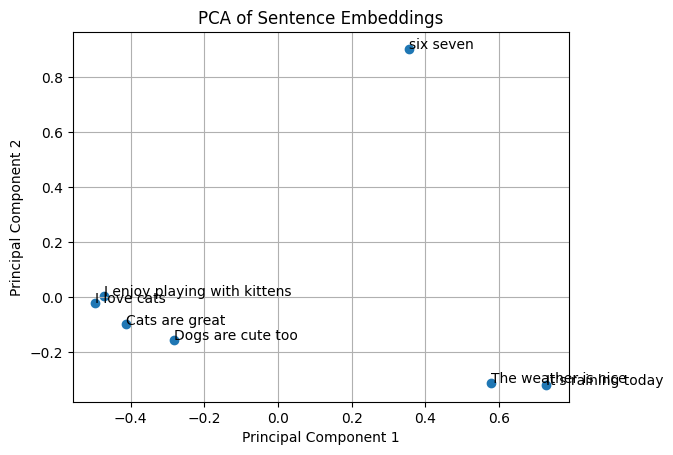

In [ ]:
# Add more sentences for better visualization
sentences.extend([
    "I enjoy playing with kittens",
    "Dogs are cute too",
    "The weather is nice",
    "It's raining today"
])
embeddings = model.encode(sentences)

from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
# Reduce to 2D for visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])
for i, sentence in enumerate(sentences):
    plt.annotate(sentence, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]))
plt.title("PCA of Sentence Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()



### Key Takeaways

- LLMs are simple to use: you send text → the model generates a response.

- Everything is measured in **tokens**, not words.  
  This affects both **cost** and **limits**.

- You pay for:
  - input tokens (what you send)
  - output tokens (what the model generates)

- Embeddings turn text into numbers (vectors).  
  Similar meaning → similar vectors.

- This is the foundation for many real systems:
  search, recommendations, and RAG.